# **Security incidents**

Dataset contains a comprehensive record of network security incidents, offering detailed insights into intrusion patterns and threat behaviour across an enterprise network. It provides information about the network traffic characteristics, connection endpoints and protocols, detection system outputs, device and user context, and response actions taken, to facilitate understanding of attack classification and triage in security operations. The goal is to try to predict the severity of the attack associated with a logged incident. The dataset has the following fields:

- Timestamp;

- Source IP Address;

- Destination IP Address;

- Source Port;

- Destination Port;

- Protocol;

- Packet Length;

- Packet Type;

- Traffic Type;

- Payload Data;

- Malware Indicators;

- Anomaly Scores;

- Alerts/Warnings;

- Attack Type;

- Attack Signature;

- Action Taken;

- User Information;

- Device Information;

- Network Segment;

- Geo-location Data;

- Proxy Information;

- Firewall Logs;

- IDS/IPS Alerts;

- Log Source;

## **Imports libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style("whitegrid")
sns.set_palette('viridis')
sns.color_palette(palette='viridis')

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [ ]:
plt.set_loglevel('warning')

## **Load Dataset**

In [ ]:
df = pd.read_csv("data.csv")

## **Inspect Dataset**

In [ ]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [ ]:
df['Timestamp'] = df['Timestamp'].astype('datetime64[ns]')

In [ ]:
num_features = df.select_dtypes(include='number').columns.tolist()
num_features.append('Timestamp')
num_features.remove('Destination Port')
num_features.remove('Source Port')
print(f'Continuous features({len(num_features)}):')
print('Name\t\tMissing values')

for feature in num_features:
  print(feature,'\t',df[feature].isna().sum())

Continuous features(3):
Name		Missing values
Packet Length 	 0
Anomaly Scores 	 0
Timestamp 	 0


In [ ]:
cat_features = df.loc[:,df.nunique()>2].select_dtypes(exclude='number').columns.tolist()
cat_features.remove('Timestamp')
cat_features.append('Destination Port')
cat_features.append('Source Port')
print(f'Categorical features({len(cat_features)}):')
print('Name','Unique','Missing values',sep='\t\t')

for feature in cat_features:
  print(feature,df[feature].nunique(),df[feature].isna().sum(),sep='\t')

Categorical features(15):
Name		Unique		Missing values
Source IP Address	40000	0
Destination IP Address	40000	0
Protocol	3	0
Traffic Type	3	0
Payload Data	40000	0
Attack Type	3	0
Action Taken	3	0
Severity Level	3	0
User Information	32389	0
Device Information	32104	0
Network Segment	3	0
Geo-location Data	8723	0
Proxy Information	20148	19851
Destination Port	29895	0
Source Port	29761	0


In [ ]:
bin_cols = df.loc[:,df.nunique()<=2].select_dtypes(exclude='number').columns.tolist()
print(f'Binary features({len(bin_cols)}):\n')

for col in bin_cols:
  print('Feature', col, 'has', df[col].isna().sum(), 'missing values,',
        'and the following unique values:',df[col].unique(),'\n')

Binary features(7):

Feature Packet Type has 0 missing values, and the following unique values: ['Data' 'Control'] 

Feature Malware Indicators has 20000 missing values, and the following unique values: ['IoC Detected' nan] 

Feature Alerts/Warnings has 20067 missing values, and the following unique values: [nan 'Alert Triggered'] 

Feature Attack Signature has 0 missing values, and the following unique values: ['Known Pattern B' 'Known Pattern A'] 

Feature Firewall Logs has 19961 missing values, and the following unique values: ['Log Data' nan] 

Feature IDS/IPS Alerts has 20050 missing values, and the following unique values: [nan 'Alert Data'] 

Feature Log Source has 0 missing values, and the following unique values: ['Server' 'Firewall'] 



There are 25 features in total.

*   The 3 continuous features have no missing data, which is great.

*   The 15 categorical ones have mostly low-cardinality, however some exceptions exist - such as IP Addresses. BUT, they need feature engineering because in this state they cannot be used for any encoding. The only with missing values is Proxy Information,but it also has all the values unique, so it will also be used in feature engineering.
    *    Although the ports are numerical values, 8080 port is not somehow worse than port 8081 or 9283, so they are also categorical features, though with high cardinality.

*   The 7 binary features are captivating. The majority of the features with missing values(4) are there. In fact, they just represent that some event has occurred, be it a firewall or an alert.


In [ ]:
df[num_features].describe()

,Packet Length,Anomaly Scores,Timestamp
count,40000.000000,40000.000000,40000
mean,781.452725,50.113473,2021-11-22 06:17:52.200800256
min,64.000000,0.000000,2020-01-01 00:43:27
25%,420.000000,25.150000,2020-12-12 19:56:28.500000
50%,782.000000,50.345000,2021-11-21 18:12:51
75%,1143.000000,75.030000,2022-10-30 08:48:10.500000
max,1500.000000,100.000000,2023-10-11 19:34:23
std,416.044192,28.853598,NaN


It is a more detailed description of continuous features.

In the dataset provided, there are attacks from 2020 to 2023.
The anomaly scores might be uniformly distributed(but it needs further investigation).
The packet length varies from 64 to 1500.

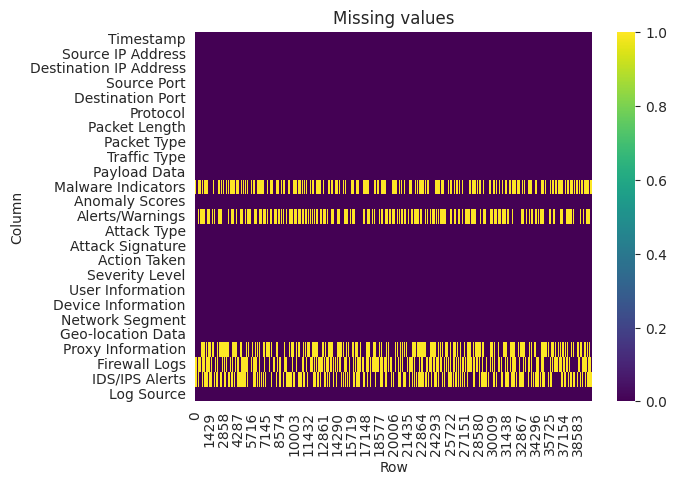

In [ ]:
sns.heatmap(df.isnull().T, cmap='viridis', square=False, norm=None)
plt.title('Missing values')
plt.xlabel('Row')
plt.ylabel('Column')
plt.show()

## **Data Analysis**

In [ ]:
num_features_1 = num_features.copy()
num_features_1.remove('Timestamp')

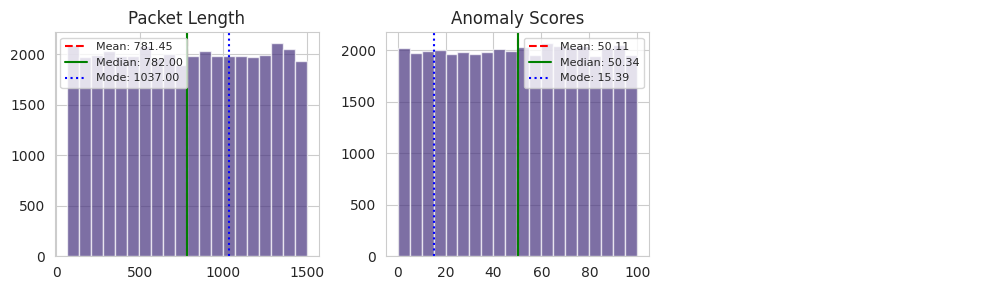

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(num_features_1) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 3))
axs = axs.flatten()

for feature, ax in zip(num_features_1, axs):
    data = df[feature].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(feature)
    ax.legend(fontsize=8)

for ax in axs[len(num_features_1):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

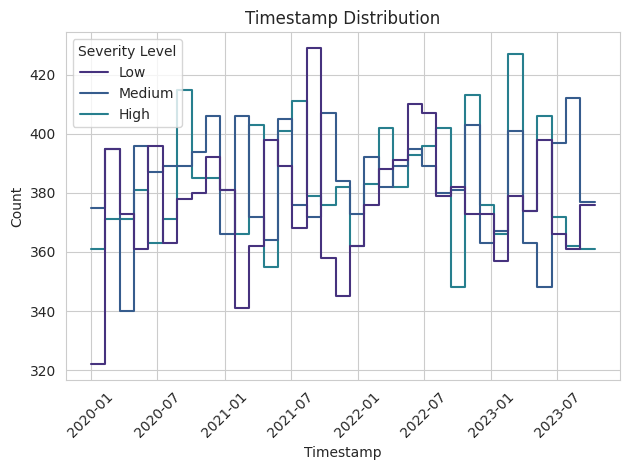

In [ ]:
sns.histplot(data=df, x='Timestamp', hue='Severity Level', element='step', fill=False)
plt.title('Timestamp Distribution')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

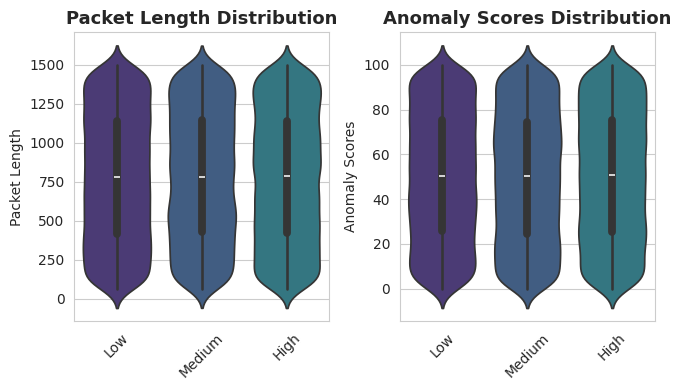

In [ ]:
ncols = 3
nrows = int(np.ceil(len(num_features_1) / n_cols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4))
axes = axes.flatten()

for i, feature in enumerate(num_features_1):
  sns.violinplot(data=df, x='Severity Level', y=feature, hue='Severity Level', inner='box', ax=axes[i])
  axes[i].set_title(feature)
  axes[i].tick_params(axis='x', rotation=45)
  axes[i].set_title(f'{feature} Distribution', fontsize=13, fontweight='bold')
  axes[i].set_xlabel('')

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

In [ ]:
low_card_cat_features = df.loc[:,df.nunique() < 10].select_dtypes(exclude='number').columns.tolist()

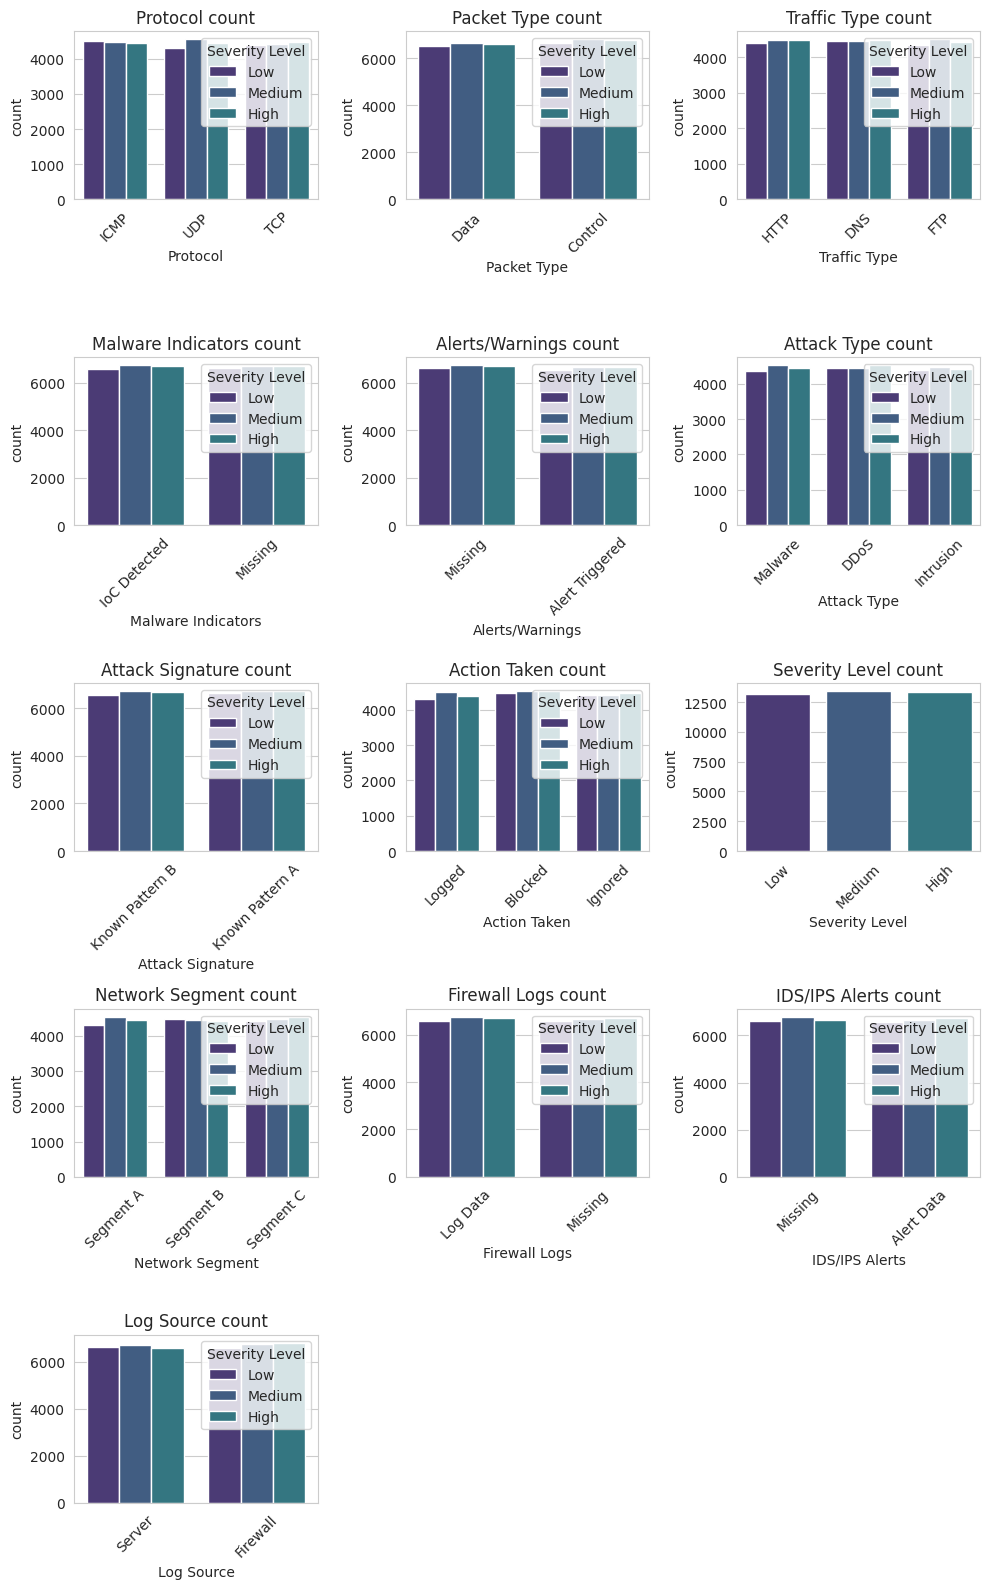

In [ ]:
ncols = 3
nrows = int(np.ceil(len(low_card_cat_features) / n_cols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 16))
axes = axes.flatten()
data = df[low_card_cat_features].copy()
data = data.fillna('Missing')

for i, feature in enumerate(low_card_cat_features):
  sns.countplot(data=data, x=feature, hue='Severity Level', ax=axes[i])
  axes[i].set_title(f'{feature} count')
  axes[i].tick_params(axis='x', rotation=45)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

In [ ]:
import ipaddress

In [ ]:
def classify_ip(ip_str):
    if pd.isna(ip_str):
        return 'No Proxy'
    try:
        ip = ipaddress.ip_address(ip_str)
        return 'Private' if ip.is_private else 'Public'
    except ValueError:
        return 'Invalid'

df['Network Type'] = df['Proxy Information'].apply(classify_ip)

In [ ]:
df['Proxy Information'].nunique()

20148

In [ ]:
df['Proxy Engineering'] = df['Proxy Information'].map(classify_ip)

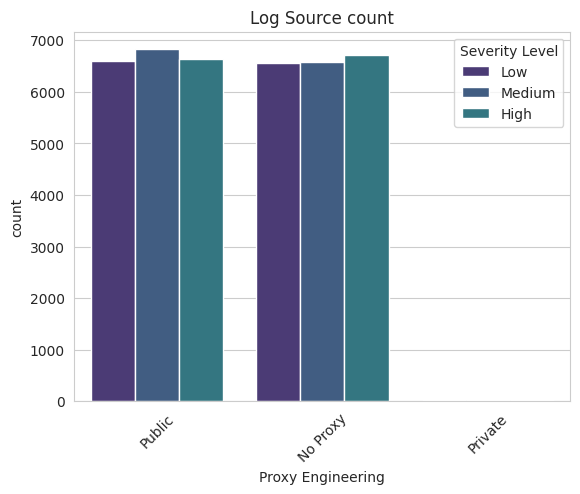

In [ ]:
sns.countplot(data=df, x='Proxy Engineering', hue='Severity Level')
plt.title(f'{feature} count')
plt.tick_params(axis='x', rotation=45)

Ehm.... Maybe there are no private proxies?

In [ ]:
len(df[df['Proxy Engineering'] == 'Private'])

84

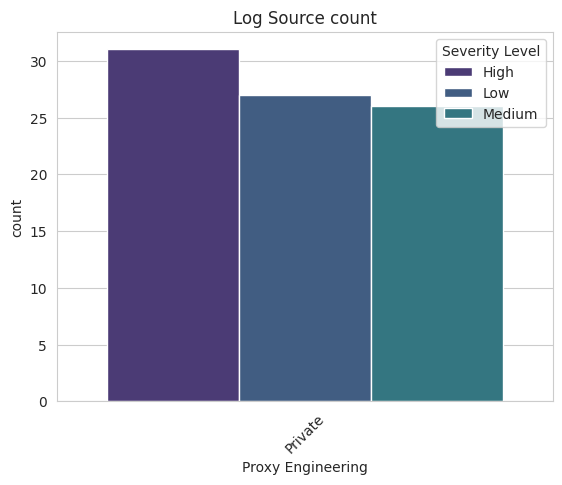

In [ ]:
sns.countplot(data=df[df['Proxy Engineering'] == 'Private'], x='Proxy Engineering', hue='Severity Level')
plt.title(f'{feature} count')
plt.tick_params(axis='x', rotation=45)

It turns out there are almost no private networks used, so it is better to just map Proxy Information as proxy / no proxy.

In [ ]:
df['Proxy Used'] = df['Proxy Information'].notna()

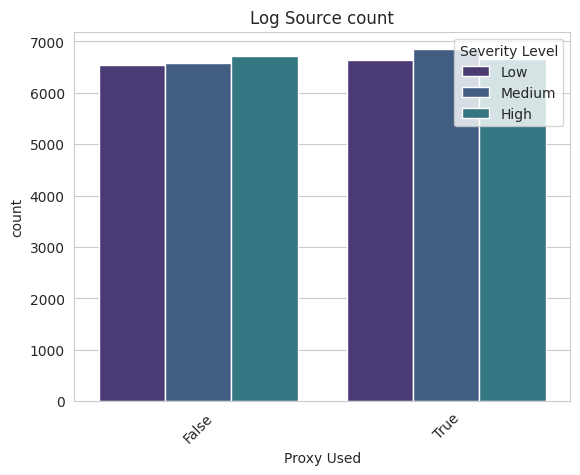

In [ ]:
sns.countplot(data=df, x='Proxy Used', hue='Severity Level')
plt.title(f'{feature} count')
plt.tick_params(axis='x', rotation=45)

In [ ]:
df.drop(['Proxy Information', 'Proxy Engineering'], axis=1, inplace=True)